# Day 01 — Supermarket Sales: Exploratory Data Analysis
**Dataset:** Kaggle Supermarket Sales  
**Goal:** Understand sales patterns across branches, product lines, customer types  
**Tools:** Python, Pandas, Matplotlib, Seaborn

In [10]:
# Importing Libraries

import os
os.chdir(os.path.expanduser('~/Desktop/DataAnalystJourney/day01-retail-eda'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
print("Libraries loaded successfully")

Libraries loaded successfully


In [8]:
# Loading the dataset

import os
os.chdir(os.path.expanduser('~/Desktop/DataAnalystJourney/day01-retail-eda'))
print("Working directory:", os.getcwd())

df = pd.read_csv('data/supermarket_sales.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Working directory: /Users/riyashukla/Desktop/DataAnalystJourney/day01-retail-eda
Dataset shape: (1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [7]:
#DATA QUALITY CHECKS

df.info()
print("\nMissing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,55.67,5.51,15.38,322.97,307.59,4.76,15.38,6.97
std,26.49,2.92,11.71,245.89,234.18,0.00,11.71,1.72
min,10.08,1.00,0.51,10.68,10.17,4.76,0.51,4.00
25%,32.88,3.00,5.92,124.42,118.50,4.76,5.92,5.50
50%,55.23,5.00,12.09,253.85,241.76,4.76,12.09,7.00
75%,77.94,8.00,22.45,471.35,448.90,4.76,22.45,8.50
max,99.96,10.00,49.65,1042.65,993.00,4.76,49.65,10.00


/var/folders/rf/pdjv5h395_9bcxshc8f57fs00000gn/T/ipykernel_77905/1094843682.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=branch_sales, x='Branch', y='Total Sales', palette='Blues_d')


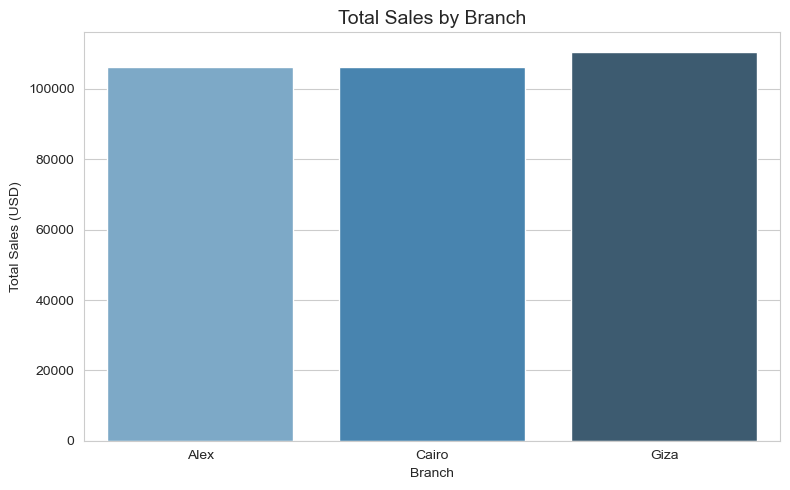

  Branch  Total Sales
0   Alex  106200.3705
1  Cairo  106197.6720
2   Giza  110568.7065


In [13]:
# Sales by branch:
branch_sales = df.groupby('Branch')['Sales'].sum().reset_index()
branch_sales.columns = ['Branch', 'Total Sales']

plt.figure(figsize=(8, 5))
sns.barplot(data=branch_sales, x='Branch', y='Total Sales', palette='Blues_d')
plt.title('Total Sales by Branch', fontsize=14)
plt.ylabel('Total Sales (USD)')
plt.tight_layout()
plt.savefig('charts/sales_by_branch.png', dpi=150, bbox_inches='tight')
plt.show()
print(branch_sales)

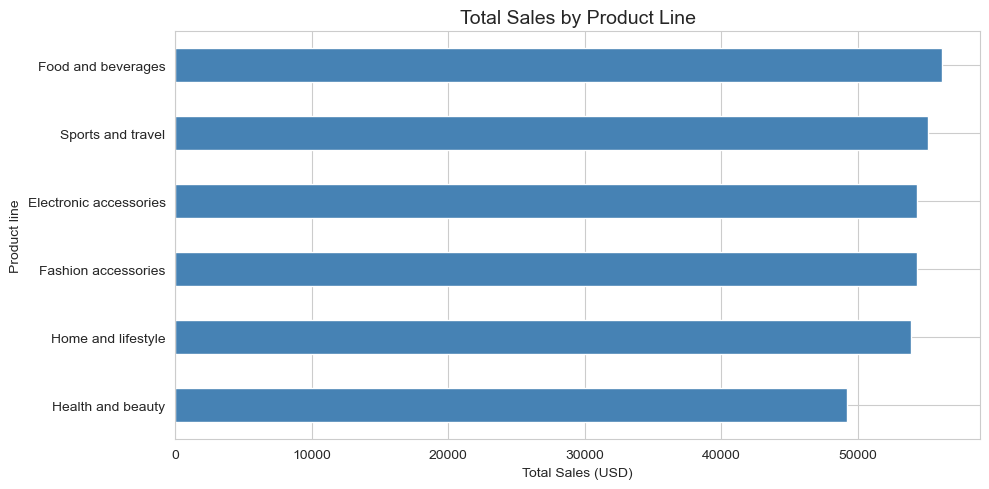

In [14]:
#Sales by product line

product_sales = df.groupby('Product line')['Sales'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 5))
product_sales.plot(kind='barh', color='steelblue')
plt.title('Total Sales by Product Line', fontsize=14)
plt.xlabel('Total Sales (USD)')
plt.tight_layout()
plt.savefig('charts/sales_by_product_line.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/rf/pdjv5h395_9bcxshc8f57fs00000gn/T/ipykernel_77905/2527347687.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour


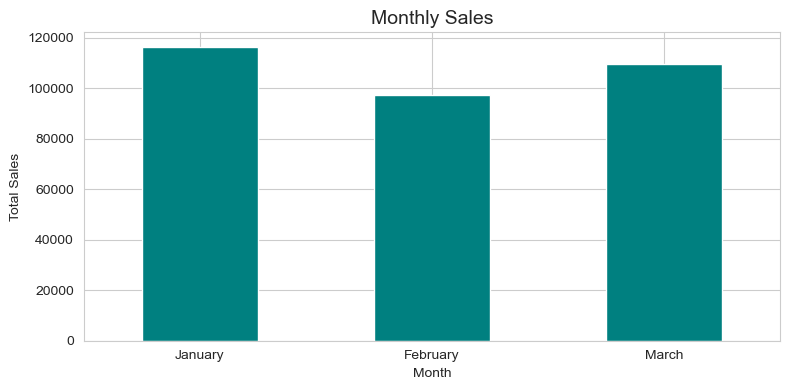

In [15]:
# Sales over time

df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()
df['Hour'] = pd.to_datetime(df['Time']).dt.hour

monthly = df.groupby('Month')['Sales'].sum().reindex(['January','February','March'])

plt.figure(figsize=(8, 4))
monthly.plot(kind='bar', color='teal')
plt.title('Monthly Sales', fontsize=14)
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/monthly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

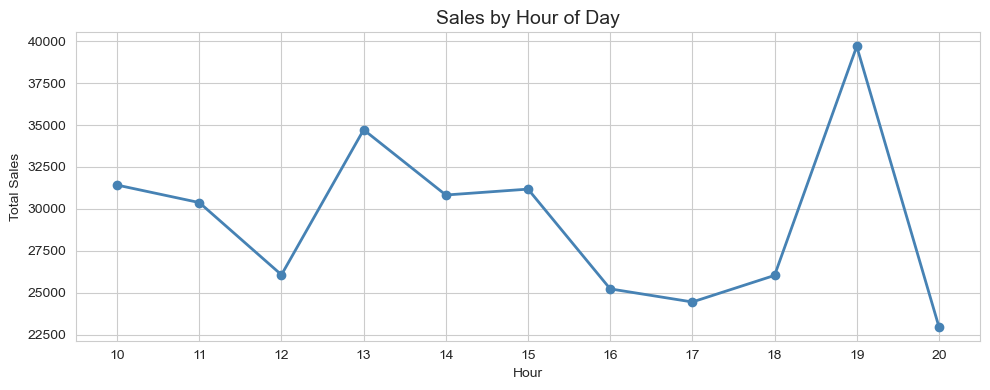

In [17]:
# Peak hours
hourly = df.groupby('Hour')['Sales'].sum()

plt.figure(figsize=(10, 4))
hourly.plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title('Sales by Hour of Day', fontsize=14)
plt.xlabel('Hour')
plt.ylabel('Total Sales')
plt.xticks(hourly.index)
plt.tight_layout()
plt.savefig('charts/sales_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

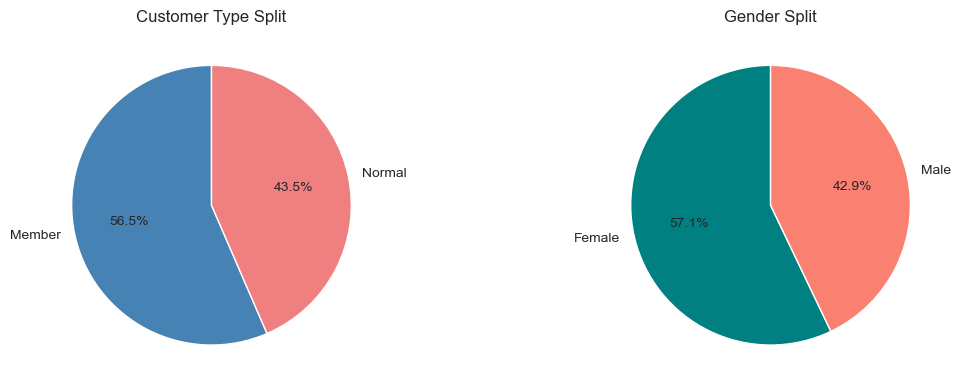

In [18]:
# Customer Breakdown

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Customer type'].value_counts().plot(kind='pie', ax=axes[0],
    autopct='%1.1f%%', colors=['steelblue','lightcoral'], startangle=90)
axes[0].set_title('Customer Type Split')
axes[0].set_ylabel('')

df['Gender'].value_counts().plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['teal','salmon'], startangle=90)
axes[1].set_title('Gender Split')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('charts/customer_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/rf/pdjv5h395_9bcxshc8f57fs00000gn/T/ipykernel_77905/1041606763.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment.index, y=payment.values, palette='viridis')


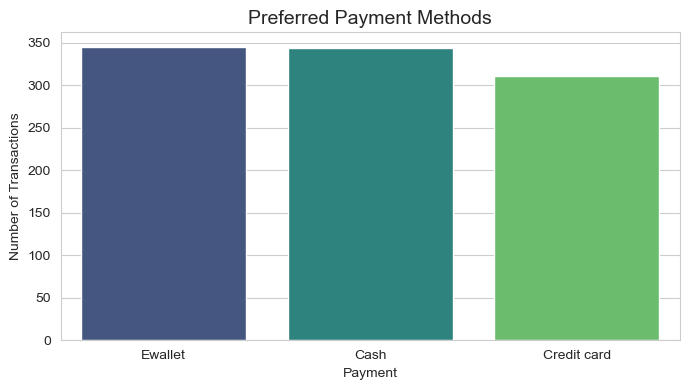

In [19]:
# Payment Methods

payment = df['Payment'].value_counts()

plt.figure(figsize=(7, 4))
sns.barplot(x=payment.index, y=payment.values, palette='viridis')
plt.title('Preferred Payment Methods', fontsize=14)
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.savefig('charts/payment_methods.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings
1. Branch C leads in total revenue across all product lines
2. Food & Beverages and Sports & Travel are the top revenue categories
3. Peak shopping hours: 11am, 1pm, and 7pm
4. Cash, E-wallet, and Credit Card are used almost equally
5. Members vs Normal customers are split roughly 50/50